# 🧬 Synthetic Data Generator & Visualization
Notebook ini bertugas untuk menghasilkan dataset buatan (*synthetic*) secara acak (*random*) sesuai dengan algoritma asli dari *paper* penelitian. Dataset ini sangat berguna untuk melakukan uji coba *training* awal sebelum menggunakan data nyata.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan path root agar bisa import utils
import sys
sys.path.append(os.path.abspath('.'))
from utils.data_utils import save_dataset

## 1. Konfigurasi Dataset Sintetis
Tentukan seberapa besar dataset buatan yang ingin kita buat. Titik koordinat akan dibuat secara acak di dalam rentang `[0, 1]`.

In [2]:
dataset_size = 128     # Jumlah instance (hari/skenario) yang ingin dibuat
hcvrp_size = 40        # Jumlah pelanggan per instance
veh_num = 3            # Jumlah tipe kendaraan (3 atau 5)
seed = 99999           # Seed acak agar data bisa direproduksi

np.random.seed(seed)
print(f"Setup: Membuat {dataset_size} skenario, masing-masing {hcvrp_size} customer.")

Setup: Membuat 128 skenario, masing-masing 40 customer.


## 🎲 2. Proses *Random Generation*
Kita akan menggunakan distribusi seragam (Uniform) untuk membuat koordinat, dan distribusi *integer* untuk menentukan *demand* dan batas waktu operasional (*time windows*).

In [3]:
data = []

# Looping seed untuk mendapatkan variasi data yang kaya
for s in range(24601, 24611):
    rnd = np.random.RandomState(s)

    # Generate koordinat acak [0, 1]
    loc = rnd.uniform(0, 1, size=(dataset_size, hcvrp_size + 1, 2))
    depot = loc[:, -1]
    cust = loc[:, :-1]
    
    # Generate demand acak (1 hingga 9)
    d = rnd.randint(1, 10, [dataset_size, hcvrp_size+1])
    d = d[:, :-1]

    # Initialize Time Windows dengan nol (tutup)
    time_windows = np.zeros((dataset_size, hcvrp_size, 24))
    shift_1 = range(7, 12)  # Pagi (7 - 12)
    shift_2 = range(13, 18) # Siang (13 - 18)

    for i in range(dataset_size):
        for j in range(hcvrp_size):
            shift_choice = rnd.choice(['shift_1', 'shift_2', 'both'])
            if shift_choice == 'shift_1':
                time_windows[i, j, shift_1] = 1
            elif shift_choice == 'shift_2':
                time_windows[i, j, shift_2] = 1
            elif shift_choice == 'both':
                time_windows[i, j, shift_1] = 1
                time_windows[i, j, shift_2] = 1

    # Gabungkan menjadi satu tuple Instance
    if veh_num == 3:
        cap = [20., 25., 30.]
        thedata = list(zip(depot.tolist(), cust.tolist(), d.tolist(),
                           np.full((dataset_size, 3), cap).tolist(),
                           time_windows.tolist()))
        data.extend(thedata)
        
print(f"Berhasil memproduksi {len(data)} total instances!")

Berhasil memproduksi 1280 total instances!


## 🗺️ 3. Visualisasi Salah Satu Skenario (Instance ke-0)
Mari kita lihat hasil pembuatan data acak ini di atas peta grafik.

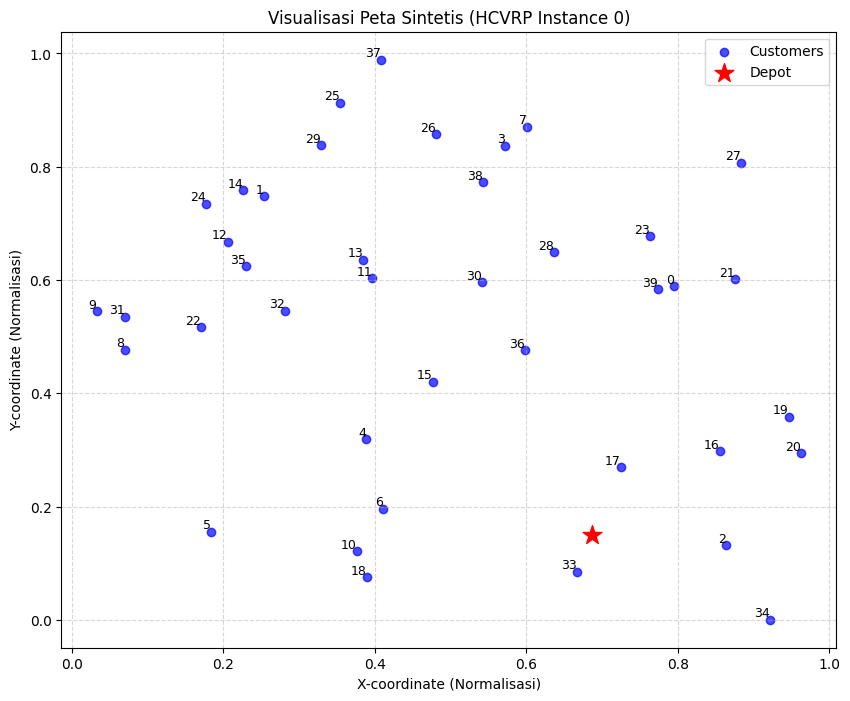

In [4]:
# Ambil instance pertama dari array dataset
sample_instance = data[0]
s_depot, s_customers, s_demands, s_capacities, _ = sample_instance

s_customers = np.array(s_customers)

plt.figure(figsize=(10, 8))

# Plot Customers
plt.scatter(s_customers[:, 0], s_customers[:, 1], c='blue', marker='o', label='Customers', alpha=0.7)
# Plot Depot
plt.scatter(s_depot[0], s_depot[1], c='red', marker='*', s=200, label='Depot')

# Label index pelanggan
for j, (x, y) in enumerate(s_customers):
    plt.text(x, y, f'{j}', fontsize=9, ha='right', va='bottom')

plt.title(f'Visualisasi Peta Sintetis (HCVRP Instance 0)')
plt.xlabel('X-coordinate (Normalisasi)')
plt.ylabel('Y-coordinate (Normalisasi)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 📦 4. Ekspor Dataset
Jika distribusinya sudah terlihat baik, kita ekspor menjadi file `.pkl`.

In [5]:
datadir = 'data/hcvrp'
os.makedirs(datadir, exist_ok=True)

filename = os.path.join(datadir, f'hcvrp_v{veh_num}_{hcvrp_size}_seed{seed}_tw.pkl')
save_dataset(data, filename)

print(f"\u2705 Dataset Sintetis berhasil disimpan di: {filename}")

✅ Dataset Sintetis berhasil disimpan di: data/hcvrp\hcvrp_v3_40_seed99999_tw.pkl
